In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/My\ Drive/Dataset/Fundus_Dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/4189d4e631ec.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/419406328dcd.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/423abbaa5fad.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/4242c0d87f57.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/4246ed634f25.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/4289af3afbd2.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/42a67337fa8e.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/42a850acd2ac.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/42b08dca9b2f.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/42b93b574f23.png  
  inflating: /content/dataset/Fundus Dataset/DR Severity/Moderate/435d900fa7b2.png  
  inflating: /

(224, 224, 3)


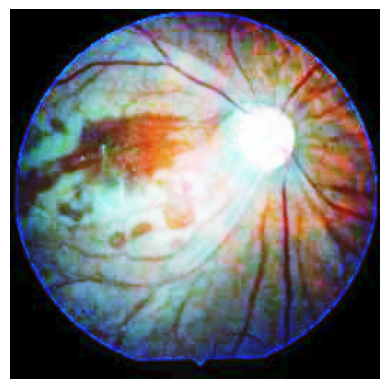

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    image[:, :, 0] = cv2.equalizeHist(image[:, :, 0])
    image[:, :, 1] = cv2.equalizeHist(image[:, :, 1])
    image[:, :, 2] = cv2.equalizeHist(image[:, :, 2])
    image = image / 255.0

    return image

sample_image = preprocess_image('/content/dataset/Fundus Dataset/Glaucoma/Glaucoma_Positive/_0_4517448.jpg')

print(sample_image.shape)

plt.imshow(sample_image)
plt.axis('off')
plt.show()


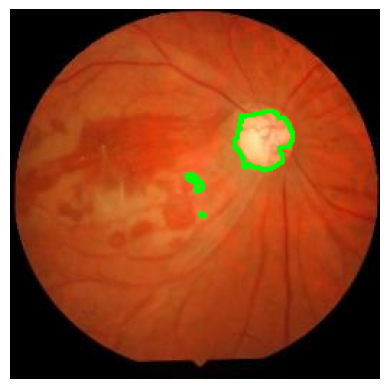

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_optic_disc(image_path):

    image = cv2.imread(image_path)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

    _, thresholded_image = cv2.threshold(blurred_image, 150, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresholded_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(image, contours, -1, (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

image_path = '/content/dataset/Fundus Dataset/Glaucoma/Glaucoma_Positive/_0_4517448.jpg'
detect_optic_disc(image_path)


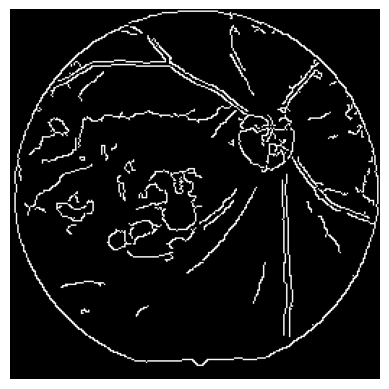

In [ ]:
def enhance_vessels(image_path):
    image = cv2.imread(image_path)

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(gray_image)

    edges = cv2.Canny(enhanced_image, 100, 200)

    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    plt.show()

image_path = '/content/dataset/Fundus Dataset/Glaucoma/Glaucoma_Positive/_0_4517448.jpg'
enhance_vessels(image_path)


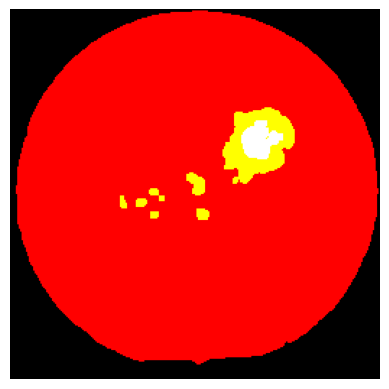

In [ ]:
def segment_vessels(image_path):

    image = cv2.imread(image_path)

    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    blurred_image = cv2.GaussianBlur(rgb_image, (5, 5), 0)

    _, binary_image = cv2.threshold(blurred_image, 120, 255, cv2.THRESH_BINARY)

    kernel = np.ones((3, 3), np.uint8)
    dilated_image = cv2.dilate(binary_image, kernel, iterations=1)

    plt.imshow(dilated_image, cmap='gray')
    plt.axis('off')
    plt.show()

image_path = '/content/dataset/Fundus Dataset/Glaucoma/Glaucoma_Positive/_0_4517448.jpg'
segment_vessels(image_path)


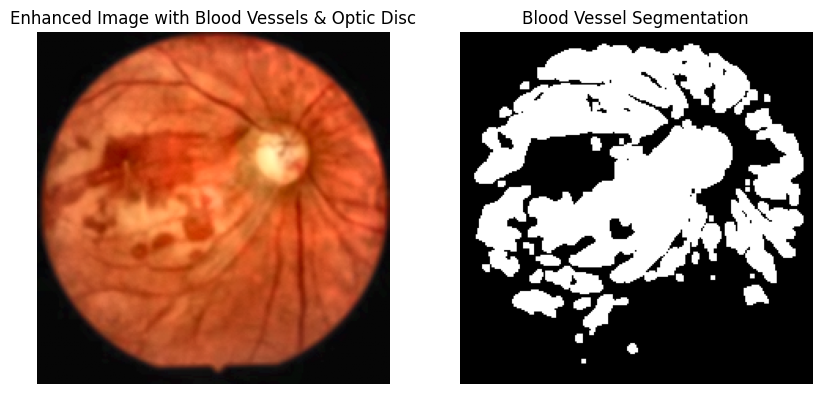

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_fundus_image(image_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (224, 224))

    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

    lab_image = cv2.cvtColor(blurred_image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab_image)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    lab_image = cv2.merge((cl, a, b))
    enhanced_image = cv2.cvtColor(lab_image, cv2.COLOR_LAB2RGB)

    gray_image = cv2.cvtColor(enhanced_image, cv2.COLOR_RGB2GRAY)
    _, binary_image = cv2.threshold(gray_image, 120, 255, cv2.THRESH_BINARY)

    kernel = np.ones((3, 3), np.uint8)
    dilated_image = cv2.dilate(binary_image, kernel, iterations=1)

    gray_image_for_disc = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred_image_for_disc = cv2.GaussianBlur(gray_image_for_disc, (5, 5), 0)

    _, thresholded_image = cv2.threshold(blurred_image_for_disc, 150, 255, cv2.THRESH_BINARY)


    normalized_image = enhanced_image / 255.0

    plt.figure(figsize=(10, 8))

    plt.subplot(1, 2, 1)
    plt.imshow(normalized_image)
    plt.title("Enhanced Image with Blood Vessels & Optic Disc")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(dilated_image, cmap='gray')
    plt.title("Blood Vessel Segmentation")
    plt.axis('off')

    plt.show()

    return normalized_image, dilated_image

image_path = '/content/dataset/Fundus Dataset/Glaucoma/Glaucoma_Positive/_0_4517448.jpg'
preprocessed_image, vessel_image = preprocess_fundus_image(image_path)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess(image_path, category, label):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (1024, 1024))

    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

    lab_image = cv2.cvtColor(blurred_image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab_image)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    lab_image = cv2.merge((cl, a, b))

    enhanced_image = cv2.cvtColor(lab_image, cv2.COLOR_LAB2RGB)
    gray_image = cv2.cvtColor(enhanced_image, cv2.COLOR_RGB2GRAY)

    _, binary_image = cv2.threshold(gray_image, 120, 255, cv2.THRESH_BINARY)
    kernel = np.ones((3, 3), np.uint8)

    dilated_image = cv2.dilate(binary_image, kernel, iterations=1)

    gray_image_for_disc = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    blurred_image_for_disc = cv2.GaussianBlur(gray_image_for_disc, (5, 5), 0)

    _, thresholded_image = cv2.threshold(blurred_image_for_disc, 150, 255, cv2.THRESH_BINARY)

    sharpened_image = cv2.addWeighted(enhanced_image, 1.5, blurred_image, -0.5, 0)

    final_image = sharpened_image.astype(np.uint8)

    image_name = image_path.split('/')[-1]
    save_preprocessed_image(final_image, category, label, image_name)




In [ ]:
import cv2
import numpy as np
import os

def preprocess(image_path, category, label, output_size=(512, 512)):
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize (Optimize for model input)
    image = cv2.resize(image, output_size)

    # Apply Gaussian Blur (to reduce noise)
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

    # Convert to LAB color space & Apply CLAHE
    lab_image = cv2.cvtColor(blurred_image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab_image)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced_lab = cv2.merge((l, a, b))
    enhanced_image = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

    # Convert to Grayscale (for additional features)
    gray_image = cv2.cvtColor(enhanced_image, cv2.COLOR_RGB2GRAY)

    # Apply Adaptive Thresholding (better than fixed threshold)
    binary_image = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)

    # Apply Edge Enhancement (Sharpening)
    sharpened = cv2.addWeighted(enhanced_image, 1.2, blurred_image, -0.3, 0)

    # Save Preprocessed Image
    final_image = sharpened.astype(np.uint8)
    image_name = os.path.basename(image_path)
    save_preprocessed_image(final_image, category, label, image_name)


In [ ]:
import cv2
import numpy as np
import os
from PIL import Image

def create_folders():
    base_path = '/content/drive/MyDrive/updated_preprocessed_dataset'
    if not os.path.exists(base_path):
        os.mkdir(base_path)

    dr_path = os.path.join(base_path, 'DR_Presence')
    normal_path = os.path.join(base_path, 'Glaucoma')

    if not os.path.exists(dr_path):
        os.mkdir(dr_path)
    if not os.path.exists(normal_path):
        os.mkdir(normal_path)

    if not os.path.exists(os.path.join(dr_path, 'DR_Negative')):
        os.mkdir(os.path.join(dr_path, 'DR_Negative'))
    if not os.path.exists(os.path.join(dr_path, 'DR_Positive')):
        os.mkdir(os.path.join(dr_path, 'DR_Positive'))

    if not os.path.exists(os.path.join(normal_path, 'Glaucoma_Negative')):
        os.mkdir(os.path.join(normal_path, 'Glaucoma_Negative'))
    if not os.path.exists(os.path.join(normal_path, 'Glaucoma_Positive')):
        os.mkdir(os.path.join(normal_path, 'Glaucoma_Positive'))

def save_preprocessed_image(image, category, label, image_name):
    save_path = f'/content/drive/MyDrive/updated_preprocessed_dataset/{category}/{label}/{image_name}'
    pil_image = Image.fromarray(image)
    pil_image.save(save_path)


def process_folder(folder_path, category, label):
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        if os.path.isfile(image_path) and image_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            preprocess(image_path, category, label)

create_folders()

dr_positive_folder = '/content/dataset/Fundus Dataset/DR Presence/DR_Positive'
dr_negative_folder = '/content/dataset/Fundus Dataset/DR Presence/DR_Negative'

gn_folder = '/content/dataset/Fundus Dataset/Glaucoma/Glaucoma_Negative'
gp_folder = '/content/dataset/Fundus Dataset/Glaucoma/Glaucoma_Positive'

process_folder(dr_positive_folder, 'DR_Presence', 'DR_Positive')
process_folder(dr_negative_folder, 'DR_Presence', 'DR_Negative')

process_folder(gn_folder, 'Glaucoma', 'Glaucoma_Negative')
process_folder(gp_folder, 'Glaucoma', 'Glaucoma_Positive')


In [ ]:
!unzip /content/drive/My\ Drive/Dataset/updated_preprocessed_dataset.zip -d /content/dataset

Archive:  /content/drive/My Drive/Dataset/updated_preprocessed_dataset.zip
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/2f4e81787d9b.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/ca30a97e9d13.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/8273fdb4405e.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/76e589911303.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/8a01daa423f7.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/578109578b46.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/3dbc90c7ee7d.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/248139c423c4.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity/Mild/a8c54e2a4b79.png  
  inflating: /content/dataset/updated_preprocessed_dataset/DR_Severity

In [ ]:
import cv2
import numpy as np
import os
from PIL import Image, ImageEnhance
import random

def augment_image(image):
    augmented_images = []

    for angle in [-15, 15]:
        rotated = image.rotate(angle)
        augmented_images.append(rotated)

    flipped_horiz = image.transpose(method=Image.FLIP_LEFT_RIGHT)
    augmented_images.append(flipped_horiz)

    flipped_vert = image.transpose(method=Image.FLIP_TOP_BOTTOM)
    augmented_images.append(flipped_vert)

    enhancer = ImageEnhance.Brightness(image)
    for factor in [0.8, 1.2]:
        bright_image = enhancer.enhance(factor)
        augmented_images.append(bright_image)

    noisy_image = add_gaussian_noise(np.array(image))
    augmented_images.append(Image.fromarray(noisy_image))

    return augmented_images

def add_gaussian_noise(image_array):
    row, col, ch = image_array.shape
    mean = 0
    sigma = 0.03
    gauss = np.random.normal(mean, sigma, (row, col, ch))
    noisy = image_array + image_array * gauss
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

def save_augmented_images(augmented_images, category, label, image_name):
    base_path = f'/content/drive/MyDrive/updated_augmented_dataset/{category}/{label}'
    if not os.path.exists(base_path):
        os.makedirs(base_path)

    base_name = image_name.split('.')[0]
    for idx, aug_img in enumerate(augmented_images):
        save_path = os.path.join(base_path, f'{base_name}_aug_{idx}.jpeg')
        aug_img.save(save_path)

def process_and_augment_folder(folder_path, category, label):
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        if os.path.isfile(image_path) and image_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            image = Image.open(image_path).convert("RGB")
            augmented_images = augment_image(image)
            save_augmented_images(augmented_images, category, label, image_name)

dr_positive_folder = '/content/dataset/updated_preprocessed_dataset/DR_Presence/DR_Positive'
glaucoma_positive_folder = '/content/dataset/updated_preprocessed_dataset/Glaucoma/Glaucoma_Positive'

process_and_augment_folder(dr_positive_folder, 'DR_Presence', 'DR_Positive')
process_and_augment_folder(glaucoma_positive_folder, 'Glaucoma', 'Glaucoma_Positive')

dr_severe_folder = '/content/dataset/updated_preprocessed_dataset/DR_Severity/Severe'
dr_mild_folder = '/content/dataset/updated_preprocessed_dataset/DR_Severity/Mild'
dr_p_folder = '/content/dataset/updated_preprocessed_dataset/DR_Severity/Proliferate_DR'
dr_mod_folder = '/content/dataset/updated_preprocessed_dataset/DR_Severity/Moderate'



process_and_augment_folder(dr_severe_folder, 'DR_Severity', 'Severe')
process_and_augment_folder(dr_mild_folder, 'DR_Severity', 'Mild')
process_and_augment_folder(dr_p_folder, 'DR_Severity', 'Proliferate_DR')
process_and_augment_folder(dr_mod_folder, 'DR_Severity', 'Moderate')


In [ ]:
import numpy as np
import random
from PIL import Image, ImageEnhance, ImageOps
import cv2

def augment_image(image):
    augmented_images = []

    # Convert PIL Image to NumPy array
    img_array = np.array(image)

    #  1. Random Rotation (-25 to +25 degrees)
    for angle in [-25, -15, 15, 25]:
        rotated = image.rotate(angle)
        augmented_images.append(rotated)

    #  2. Horizontal Flip (Fundus images are symmetrical)
    flipped_horiz = image.transpose(Image.FLIP_LEFT_RIGHT)
    augmented_images.append(flipped_horiz)

    #  3. Random Brightness & Contrast (Adaptive)
    enhancer = ImageEnhance.Brightness(image)
    for factor in [0.6, 0.8, 1.2, 1.5]:
        bright_image = enhancer.enhance(factor)
        augmented_images.append(bright_image)

    enhancer_contrast = ImageEnhance.Contrast(image)
    for contrast_factor in [0.7, 1.3]:
        contrast_image = enhancer_contrast.enhance(contrast_factor)
        augmented_images.append(contrast_image)

    #  4. Gaussian Blur (Simulate blurry images)
    blurred = cv2.GaussianBlur(img_array, (5, 5), cv2.BORDER_DEFAULT)
    augmented_images.append(Image.fromarray(blurred))

    #  5. Add Random Gaussian Noise
    noisy_image = add_gaussian_noise(img_array)
    augmented_images.append(Image.fromarray(noisy_image))

    #  6. Random Crop & Rescale (Simulate different image framing)
    cropped_rescaled = random_crop_and_resize(img_array)
    augmented_images.append(Image.fromarray(cropped_rescaled))

    return augmented_images


# 🛠 Function to Add Gaussian Noise
def add_gaussian_noise(image_array, sigma_range=(0.02, 0.07)):
    row, col, ch = image_array.shape
    sigma = random.uniform(*sigma_range)
    gauss = np.random.normal(0, sigma, (row, col, ch))
    noisy = image_array + image_array * gauss
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy


# 🛠 Function for Random Cropping & Resizing
def random_crop_and_resize(image_array, crop_size=(180, 180), output_size=(224, 224)):
    img = Image.fromarray(image_array)
    width, height = img.size

    left = random.randint(0, width - crop_size[0])
    top = random.randint(0, height - crop_size[1])
    right = left + crop_size[0]
    bottom = top + crop_size[1]

    cropped = img.crop((left, top, right, bottom))
    resized = cropped.resize(output_size, Image.Resampling.LANCZOS)

    return np.array(resized)

def save_augmented_images(augmented_images, category, label, image_name):
    base_path = f'/content/drive/MyDrive/updated_augmented_dataset/{category}/{label}'
    if not os.path.exists(base_path):
        os.makedirs(base_path)

    base_name = image_name.split('.')[0]
    for idx, aug_img in enumerate(augmented_images):
        save_path = os.path.join(base_path, f'{base_name}_aug_{idx}.jpeg')
        aug_img.save(save_path)

def process_and_augment_folder(folder_path, category, label):
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        if os.path.isfile(image_path) and image_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            image = Image.open(image_path).convert("RGB")
            augmented_images = augment_image(image)
            save_augmented_images(augmented_images, category, label, image_name)

dr_positive_folder = '/content/dataset/updated_preprocessed_dataset/DR_Presence/DR_Positive'
glaucoma_positive_folder = '/content/dataset/updated_preprocessed_dataset/Glaucoma/Glaucoma_Positive'

process_and_augment_folder(dr_positive_folder, 'DR_Presence', 'DR_Positive')
process_and_augment_folder(glaucoma_positive_folder, 'Glaucoma', 'Glaucoma_Positive')

dr_severe_folder = '/content/dataset/updated_preprocessed_dataset/DR_Severity/Severe'
dr_mild_folder = '/content/dataset/updated_preprocessed_dataset/DR_Severity/Mild'
dr_p_folder = '/content/dataset/updated_preprocessed_dataset/DR_Severity/Proliferate_DR'
dr_mod_folder = '/content/dataset/updated_preprocessed_dataset/DR_Severity/Moderate'



process_and_augment_folder(dr_severe_folder, 'DR_Severity', 'Severe')
process_and_augment_folder(dr_mild_folder, 'DR_Severity', 'Mild')
process_and_augment_folder(dr_p_folder, 'DR_Severity', 'Proliferate_DR')
process_and_augment_folder(dr_mod_folder, 'DR_Severity', 'Moderate')


In [ ]:
def process_and_augment_folder(folder_path, category, label):
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return

    print(f"Processing folder: {folder_path}")

    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        if os.path.isfile(image_path) and image_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            print(f"Processing image: {image_name}")
            image = Image.open(image_path).convert("RGB")
            augmented_images = augment_image(image)
            save_augmented_images(augmented_images, category, label, image_name)
        else:
            print(f"Skipping non-image file: {image_name}")

#glaucoma_negative_folder = '/content/dataset/preprocessed_dataset/Glaucoma/Glaucoma_negative'


#process_and_augment_folder(glaucoma_negative_folder, 'Glaucoma', 'Glaucoma_negative')
